In [11]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import kagglehub
import os

# 1. Load the Data
dataset_path = "/content/drive/MyDrive/amazon_cells_labelled.csv"

# The dataset has multiple columns due to trailing commas (e.g., text, label, empty, empty...).
# We will read it with comma separation, and then keep only the first two columns.
try:
    df = pd.read_csv(dataset_path, header=None, on_bad_lines='skip')
    # Select the first two columns and rename them
    df = df.iloc[:, [0, 1]]
    df.columns = ['text', 'label']
    # Ensure labels are integers
    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
except Exception as e:
    print(f"Error parsing dataset: {e}")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [12]:
#2.  Download the model using kagglehub for better performance on Kaggle
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
# Load the 250-dimensional Wiki-words embedding model from tensorFlow hub
embed = hub.load(model_path)


100%|██████████| 218/218 [00:00<00:00, 359kB/s]



100%|██████████| 23.0k/23.0k [00:00<00:00, 5.59MB/s]



  0%|          | 0.00/8.27M [00:00<?, ?B/s]



  0%|          | 0.00/963M [00:00<?, ?B/s]
 12%|█▏        | 1.00M/8.27M [00:00<00:04, 1.74MB/s]

  0%|          | 1.00M/963M [00:00<09:32, 1.76MB/s]
 24%|██▍       | 2.00M/8.27M [00:00<00:01, 3.36MB/s]

  0%|          | 2.00M/963M [00:00<04:56, 3.40MB/s]
 48%|████▊     | 4.00M/8.27M [00:00<00:00, 7.05MB/s]

  0%|          | 4.00M/963M [00:00<02:21, 7.12MB/s]
100%|██████████| 8.27M/8.27M [00:00<00:00, 9.29MB/s]


  1%|          | 8.00M/963M [00:00<01:06, 14.9MB/s]

  1%|          | 12.0M/963M [00:01<00:47, 21.1MB/s]

  2%|▏         | 16.0M/963M [00:01<00:38, 25.7MB/s]

  2%|▏         | 20.0M/963M [00:01<00:33, 29.1MB/s]

  2%|▏         | 24.0M/963M [00:01<00:38, 25.3MB/s]

  3%|▎         | 28.0M/963M [00:01<00:33, 29.0MB/s]

  3%|▎         | 32.0M/963M [00:01<00:42, 23.2MB/s]

  4%|▎         | 36.0M/963M [00:01<00:36, 26.9MB/s]

  4%|▍         | 40.0M/963M [00:02<00:35, 27.0MB/s]

  4%|▍         | 43.0M/963M [00:02<00:38, 24.8MB/s]

  5%|▍         | 47.0M/963M [00:02<00:33, 28.4MB/s]


In [13]:
# 3. Define the Preprocessing Helper Functions
def get_max_length(df):
    max_length = 0
    for row in df['text']:
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)
    return max_length

def get_word2vec_enc(texts):
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

def get_padded_encoded_texts(encoded_texts, max_len):
    padded_texts_encoding = []
    for enc_text in encoded_texts:
        zero_padding_cnt = max_len - enc_text.shape[0]
        pad = np.zeros((1, 250))
        for i in range(zero_padding_cnt):
            enc_text = np.concatenate((pad, enc_text), axis=0)
        padded_texts_encoding.append(enc_text)
    return padded_texts_encoding

def preprocess(df, max_len):
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)

    X = np.array(padded_encoded_texts)
    Y = np.array(df['label'].tolist())
    return X, Y

In [14]:
# 4. Execute the Pipeline
max_length = get_max_length(df)
print(f"The maximum sequence length in the dataset is: {max_length}")

# Note: This step processes the embeddings and takes a moment
X, Y = preprocess(df, max_length)

print(f"Shape of X (Training Data): {X.shape}") # Should be (N, max_length, 250)
print(f"Shape of Y (Labels): {Y.shape}")

The maximum sequence length in the dataset is: 30
Shape of X (Training Data): (771, 30, 250)
Shape of Y (Labels): (771,)


In [17]:
from tensorflow.keras import layers, Model

# 1. Define the Input layer
# Shape is now (max_length, 250) because the words are already embedded!
inputs = layers.Input(shape=(max_length, 250))

# 2. Add the SimpleRNN layer directly
# The hidden state will have 32 dimensions
x = layers.SimpleRNN(units=32)(inputs)

# 3. Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Construct the Model
model = Model(inputs=inputs, outputs=outputs, name="Simple_RNN_Sentiment")

model.summary()

Model: "Simple_RNN_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         9,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
print("Starting training...")
history = model.fit(
    X,
    Y,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Starting training...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.5000 - loss: 0.6965 - val_accuracy: 0.5806 - val_loss: 0.6724
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6380 - loss: 0.6572 - val_accuracy: 0.6194 - val_loss: 0.6631
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6948 - loss: 0.6179 - val_accuracy: 0.6452 - val_loss: 0.6575
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7192 - loss: 0.5856 - val_accuracy: 0.6387 - val_loss: 0.6381
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7127 - loss: 0.5627 - val_accuracy: 0.6516 - val_loss: 0.6466
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7630 - loss: 0.5307 - val_accuracy: 0.6387 - val_loss: 0.6508
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7711 - loss: 0.4904 - val_accuracy: 0.6839 - val_loss: 0.6399
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7841 - loss: 0.4595 - val_accur

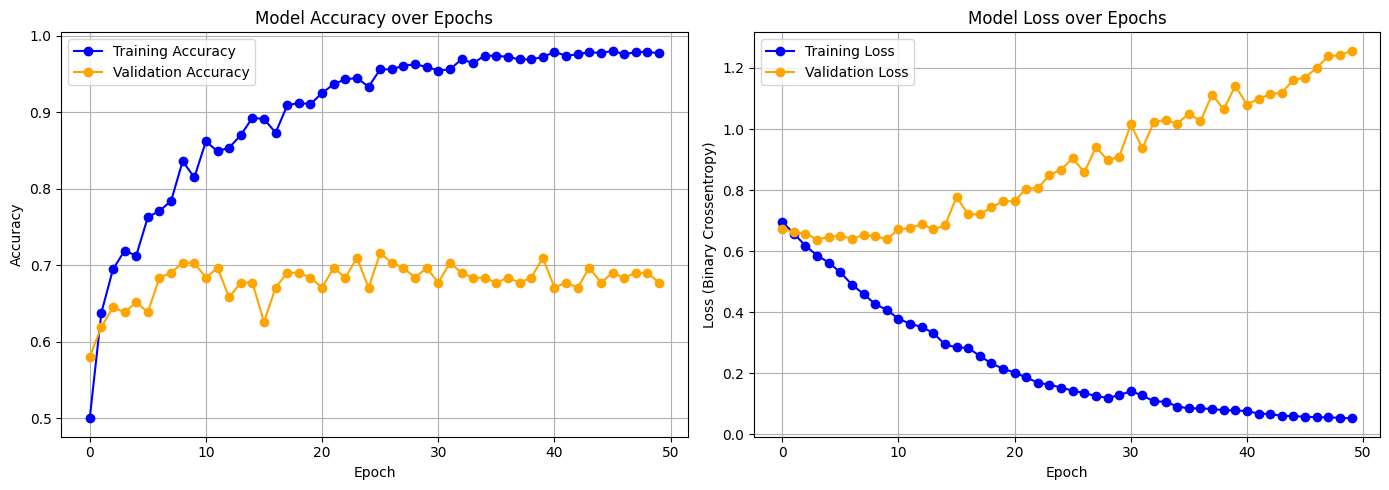

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step


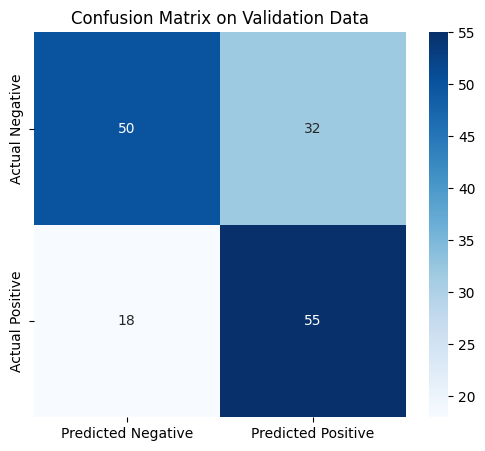

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 2. Generate a Confusion Matrix
# We use the final 20% of the data as a proxy for our validation set to match the validation_split
val_split_index = int(len(X) * 0.8)
X_val = X[val_split_index:]
Y_val = Y[val_split_index:]

# Get raw probability predictions from the model
predictions_prob = model.predict(X_val)

# Convert probabilities to binary classes (0 or 1) using a 0.5 threshold
predictions_binary = (predictions_prob > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(Y_val, predictions_binary)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix on Validation Data')
plt.show()

Model: "Smaller_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │         2,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081 (8.13 KB)

 Trainable params: 2,081 (8.13 KB)

 Non-trainable params: 0 (0.00 B)

Starting training for the Smaller Model...


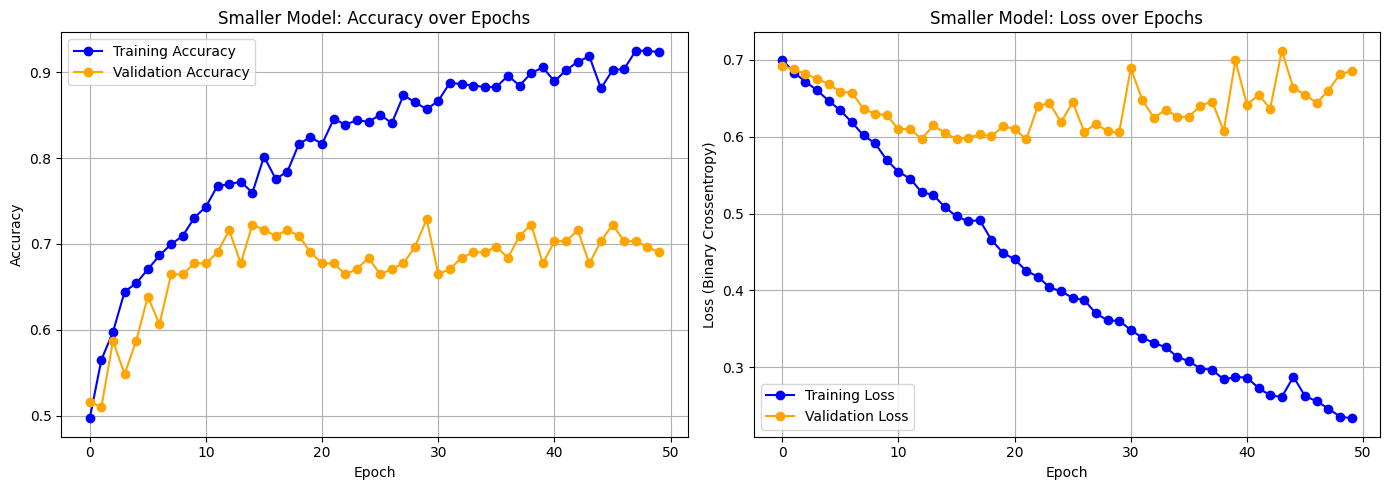

In [20]:
from tensorflow.keras import layers, Model

# 1. Define Input
inputs = layers.Input(shape=(max_length, 250))

# 2. Add a SMALLER SimpleRNN layer
# We reduce the capacity from 32 units down to just 8 units!
x = layers.SimpleRNN(units=8)(inputs)

# 3. Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Construct and Compile the Smaller Model
smaller_model = Model(inputs=inputs, outputs=outputs, name="Smaller_RNN")

smaller_model.summary()

smaller_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Smaller Model
print("Starting training for the Smaller Model...")
smaller_history = smaller_model.fit(
    X,
    Y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Plot Accuracy and Loss over Epochs for the Smaller Model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(smaller_history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(smaller_history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Smaller Model: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(smaller_history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(smaller_history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Smaller Model: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [28]:
import random
import numpy as np
import tensorflow as tf
import os

In [29]:

def set_deterministic_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_deterministic_seed(42)

In [31]:
# 1. Load the Data
dataset_path = "/content/drive/MyDrive/amazon_cells_labelled.csv"

# The dataset has multiple columns due to trailing commas (e.g., text, label, empty, empty...).
# We will read it with comma separation, and then keep only the first two columns.
try:
    df = pd.read_csv(dataset_path, header=None, on_bad_lines='skip')
    # Select the first two columns and rename them
    df = df.iloc[:, [0, 1]]
    df.columns = ['text', 'label']
    # Ensure labels are integers
    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
except Exception as e:
    print(f"Error parsing dataset: {e}")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [32]:
# 3. Define the Preprocessing Helper Functions
def get_max_length(df):
    max_length = 0
    for row in df['text']:
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)
    return max_length

def get_word2vec_enc(texts):
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

def get_padded_encoded_texts(encoded_texts, max_len):
    padded_texts_encoding = []
    for enc_text in encoded_texts:
        zero_padding_cnt = max_len - enc_text.shape[0]
        pad = np.zeros((1, 250))
        for i in range(zero_padding_cnt):
            enc_text = np.concatenate((pad, enc_text), axis=0)
        padded_texts_encoding.append(enc_text)
    return padded_texts_encoding

def preprocess(df, max_len):
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)

    X = np.array(padded_encoded_texts)
    Y = np.array(df['label'].tolist())
    return X, Y

In [34]:
# 4. Execute the Pipeline
max_length = get_max_length(df)
print(f"The maximum sequence length in the dataset is: {max_length}")

# Note: This step processes the embeddings and takes a moment
X, Y = preprocess(df, max_length)

print(f"Shape of X (Training Data): {X.shape}")
print(f"Shape of Y (Labels): {Y.shape}")

The maximum sequence length in the dataset is: 30
Shape of X (Training Data): (771, 30, 250)
Shape of Y (Labels): (771,)


In [35]:
from tensorflow.keras import layers, Model

# 1. Define the Input layer
inputs = layers.Input(shape=(max_length, 250))

# 2. Add the LSTM layer with VERY low capacity (deliberate underfitting)
x = layers.LSTM(units=4)(inputs)

# 3. Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Construct the Model
lstm_model = Model(inputs=inputs, outputs=outputs, name="Underfitting_LSTM")
lstm_model.summary()

Model: "Underfitting_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 4)              │         4,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,085 (15.96 KB)

 Trainable params: 4,085 (15.96 KB)

 Non-trainable params: 0 (0.00 B)

Starting training for the Model...


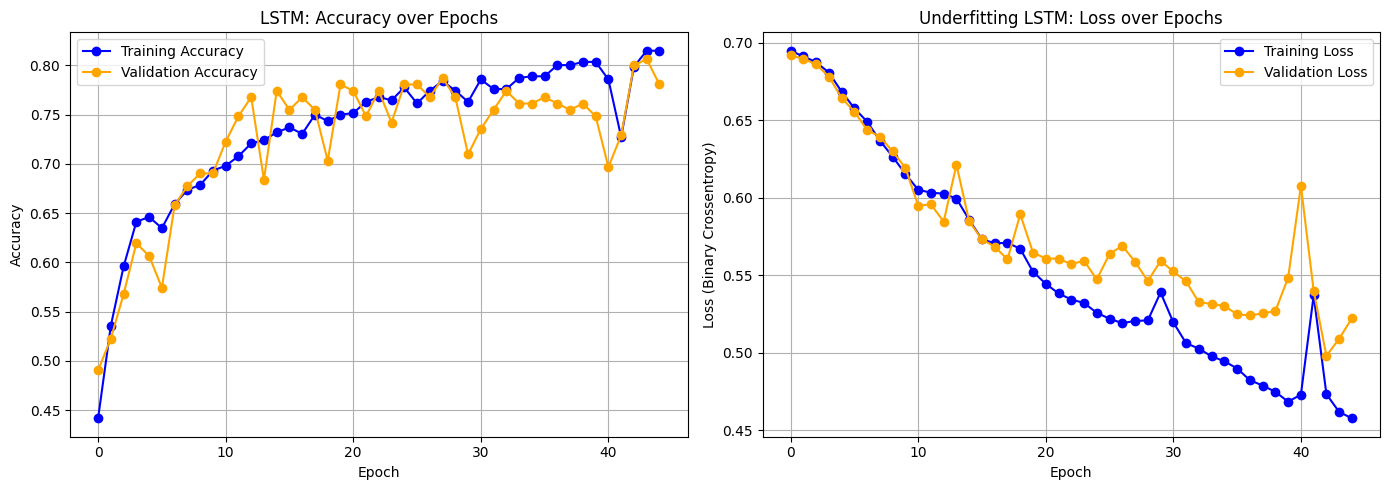

In [36]:
import matplotlib.pyplot as plt

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
print("Starting training for the Model...")
history = lstm_model.fit(
    X,
    Y,
    epochs=45,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('LSTM: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Underfitting LSTM: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Starting training for the Regularized LSTM...


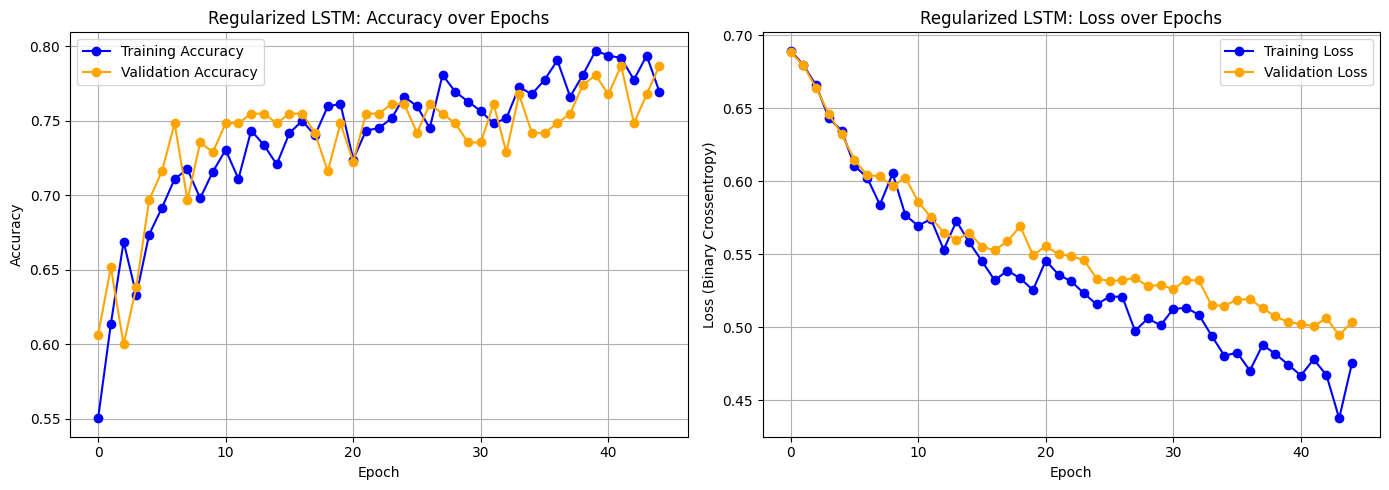

In [37]:
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# 1. Define Input
inputs = layers.Input(shape=(max_length, 250))

# 2. Add LSTM with tuned capacity and built-in Dropout
# Using 32 units gives it power to learn, and 30% dropout prevents overfitting
x = layers.LSTM(
    units=32,               # <-- CHANGED FROM 4 TO 32
    dropout=0.3,            # Drops 30% of the input connections
    recurrent_dropout=0.3   # Drops 30% of the recurrent memory connections
)(inputs)

# 3. Output Layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Build and Compile
regularized_lstm_model = Model(inputs=inputs, outputs=outputs)

regularized_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Model
print("Starting training for the Regularized LSTM...")
regularized_history = regularized_lstm_model.fit(
    X, Y,
    epochs=45,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# 6. Plot the Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(regularized_history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(regularized_history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Regularized LSTM: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(regularized_history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(regularized_history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Regularized LSTM: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# 3. Define the Preprocessing Helper Functions
def get_max_length(df):
    max_length = 0
    for row in df['text']:
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)
    return max_length

def get_word2vec_enc(texts):
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

def get_padded_encoded_texts(encoded_texts, max_len):
    padded_texts_encoding = []
    for enc_text in encoded_texts:
        zero_padding_cnt = max_len - enc_text.shape[0]
        pad = np.zeros((1, 250))
        for i in range(zero_padding_cnt):
            enc_text = np.concatenate((pad, enc_text), axis=0)
        padded_texts_encoding.append(enc_text)
    return padded_texts_encoding

def preprocess(df, max_len):
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)

    X = np.array(padded_encoded_texts)
    Y = np.array(df['label'].tolist())
    return X, Y

# 4. Execute the Pipeline
max_length = get_max_length(df)
print(f"The maximum sequence length in the dataset is: {max_length}")

# Note: This step processes the embeddings and takes a moment
X, Y = preprocess(df, max_length)

print(f"Shape of X (Training Data): {X.shape}")
print(f"Shape of Y (Labels): {Y.shape}")

The maximum sequence length in the dataset is: 30
Shape of X (Training Data): (771, 30, 250)
Shape of Y (Labels): (771,)


In [39]:
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# Define the Input layer
inputs = layers.Input(shape=(max_length, 250))

# Add the Bidirectional LSTM wrapper WITH Regularization
# We add 40% dropout to prevent the doubled parameters from overfitting
x = layers.Bidirectional(layers.LSTM(
    units=32,
    dropout=0.4,
    recurrent_dropout=0.4
))(inputs)

# Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# Construct and Compile the Model
bidirectional_model = Model(inputs=inputs, outputs=outputs, name="Bidirectional_Sentiment")

bidirectional_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bidirectional_model.summary()

Model: "Bidirectional_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        72,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,513 (283.25 KB)

 Trainable params: 72,513 (283.25 KB)

 Non-trainable params: 0 (0.00 B)

Starting Regularized Bidirectional training...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.5373 - loss: 0.6893 - val_accuracy: 0.5742 - val_loss: 0.6883
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.6266 - loss: 0.6805 - val_accuracy: 0.5806 - val_loss: 0.6814
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6510 - loss: 0.6648 - val_accuracy: 0.6000 - val_loss: 0.6660
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.6315 - loss: 0.6524 - val_accuracy: 0.6258 - val_loss: 0.6487
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.6364 - loss: 0.6379 - val_accuracy: 0.6581 - val_loss: 0.6339
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6769 - loss: 0.6309 - val_accuracy: 0.7032 - val_loss: 0.6222
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6688 - loss: 0.6205 - val_accuracy: 0.7161 - val_loss: 0.6173
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 

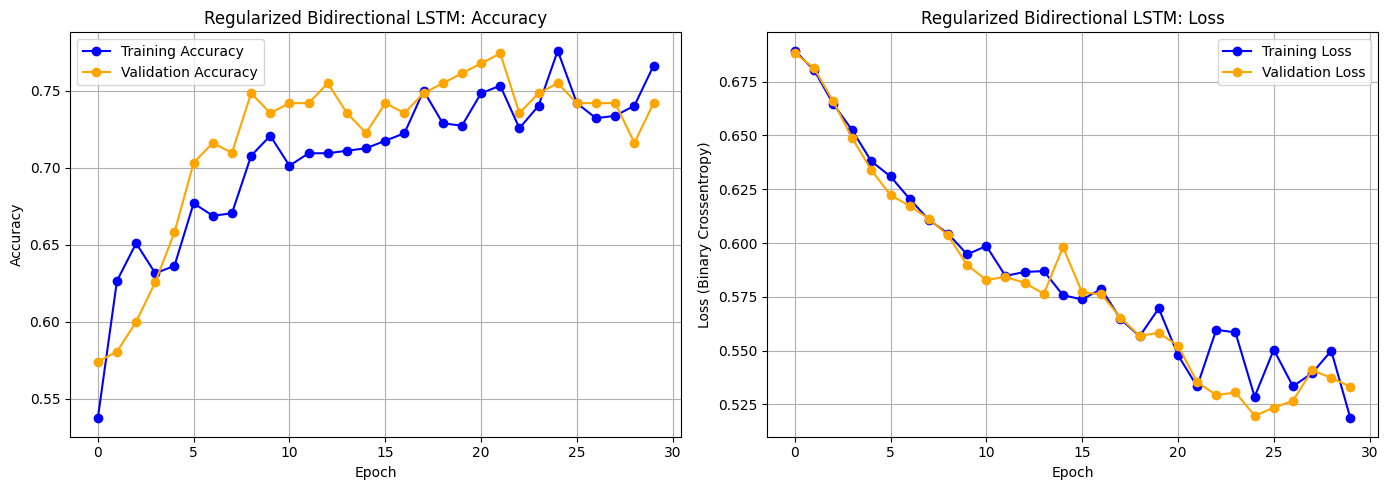

In [40]:
# Train the model (Increased to 30 epochs for regularized learning)
print("Starting Regularized Bidirectional training...")
history_bi = bidirectional_model.fit(
    X,
    Y,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

# Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_bi.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(history_bi.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Regularized Bidirectional LSTM: Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_bi.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(history_bi.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Regularized Bidirectional LSTM: Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()